In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

BASE = '/content/drive/MyDrive/Text Miners/Actual Work'
print('Connected:', BASE)

Mounted at /content/drive
Connected: /content/drive/MyDrive/Text Miners/Actual Work


In [2]:
!pip install gensim pyLDAvis scikit-learn pandas numpy ftfy --quiet

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
print('Done')

Done


In [3]:
import pandas as pd
import pickle
import sys

# Load cleaned data
df = pd.read_csv(f'{BASE}/data/MergedCleaned.csv')
print('Data shape:', df.shape)

# Load BoW matrix (LDA needs raw counts not TF-IDF)
with open(f'{BASE}/features/bow_matrix.pkl', 'rb') as f:
    bow_matrix = pickle.load(f)

with open(f'{BASE}/features/bow_vectorizer.pkl', 'rb') as f:
    bow_vectorizer = pickle.load(f)

print('BoW matrix shape:', bow_matrix.shape)
print('Vocabulary size:', len(bow_vectorizer.vocabulary_))

Data shape: (380505, 4)
BoW matrix shape: (380505, 10000)
Vocabulary size: 10000


In [4]:
sys.path.append(f'{BASE}/pre-processing')
import preprocess

df = preprocess.preprocess_dataframe(df)
print('Preprocessing done')
print(df[['comments', 'cleaned_text']].head(3))

Preprocessing done
                                            comments  \
0  We stayed in the apartment for a week and we e...   
1  My girlfriend and I recently stayed in Nuttee'...   
2  I stayed for one month at the condo and was re...   

                                        cleaned_text  
0  stayed apartment week enjoyed very much nuttee...  
1  girlfriend recently stayed nuttee condo month ...  
2  stayed one month condo realy pleased condo 19t...  


In [5]:
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# Gensim LDA needs a different format to sklearn
# Convert tokens column into gensim dictionary and corpus
tokens_list = df['tokens'].tolist()

# Build dictionary — maps each word to an ID
dictionary = corpora.Dictionary(tokens_list)

# Filter extremes — remove very rare and very common words
# no_below: ignore words appearing in fewer than 10 documents
# no_above: ignore words appearing in more than 80% of documents
dictionary.filter_extremes(no_below=10, no_above=0.8)

# Build bag-of-words corpus
corpus = [dictionary.doc2bow(tokens) for tokens in tokens_list]

print(f'Dictionary size: {len(dictionary)} words')
print(f'Corpus size: {len(corpus)} documents')
print(f'Sample document (first 5 word-count pairs): {corpus[0][:5]}')

Dictionary size: 11379 words
Corpus size: 380505 documents
Sample document (first 5 word-count pairs): [(0, 2), (1, 1), (2, 1), (3, 3), (4, 1)]


Testing topic numbers...
  Topics: 3  Coherence: 0.6550
  Topics: 5  Coherence: 0.6763
  Topics: 7  Coherence: 0.6779
  Topics: 8  Coherence: 0.6902
  Topics: 9  Coherence: 0.6776
  Topics: 10  Coherence: 0.6573
  Topics: 12  Coherence: 0.6518


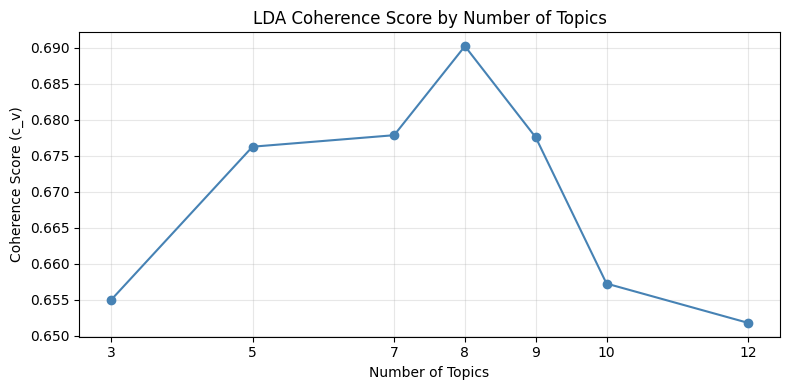


Best number of topics: 8 (coherence: 0.6902)


In [ ]:
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

# Test different numbers of topics
topic_range = [3, 5, 7, 8, 9, 10, 12,]
coherence_scores = []

print('Testing topic numbers...')
for num_topics in topic_range:
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    coherence = CoherenceModel(
        model=lda,
        texts=tokens_list,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence()
    coherence_scores.append(coherence)
    print(f'  Topics: {num_topics}  Coherence: {coherence:.4f}')

# Plot coherence scores
plt.figure(figsize=(8, 4))
plt.plot(topic_range, coherence_scores, marker='o', color='steelblue')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.title('LDA Coherence Score by Number of Topics')
plt.xticks(topic_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_num_topics = topic_range[coherence_scores.index(max(coherence_scores))]
print(f'\nBest number of topics: {best_num_topics} (coherence: {max(coherence_scores):.4f})')

In [6]:
# Train with the best number of topics from Cell 6
# Change best_num_topics if you want to override
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt


best_num_topics=7
print(f'Training LDA with {best_num_topics} topics...')

lda_model1 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=15,       # more passes = better convergence
    alpha='auto',
    per_word_topics=True
)

print('Training done.')

# Print top keywords per topic
print('\nTop 10 keywords per topic:')
for idx, topic in lda_model.print_topics(num_words=10):
    print(f'\n  Topic {idx}: {topic}')

Training LDA with 7 topics...
Training done.

Top 10 keywords per topic:


NameError: name 'lda_model' is not defined

In [7]:
# Train with the best number of topics from Cell 6
# Change best_num_topics if you want to override
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt


best_num_topics=5
print(f'Training LDA with {best_num_topics} topics...')

lda_model2 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=15,       # more passes = better convergence
    alpha='auto',
    per_word_topics=True
)

print('Training done.')

# Print top keywords per topic
print('\nTop 10 keywords per topic:')
for idx, topic in lda_model2.print_topics(num_words=10):
    print(f'\n  Topic {idx}: {topic}')

Training LDA with 5 topics...
Training done.

Top 10 keywords per topic:

  Topic 0: 0.061*"but" + 0.039*"not" + 0.031*"room" + 0.023*"bed" + 0.020*"no" + 0.013*"bathroom" + 0.013*"bit" + 0.012*"issue" + 0.011*"overall" + 0.011*"water"

  Topic 1: 0.018*"even" + 0.017*"day" + 0.015*"one" + 0.014*"airbnb" + 0.011*"made" + 0.010*"like" + 0.010*"time" + 0.010*"check" + 0.009*"also" + 0.009*"feel"

  Topic 2: 0.034*"close" + 0.033*"bts" + 0.027*"restaurant" + 0.027*"walk" + 0.023*"area" + 0.023*"station" + 0.022*"food" + 0.020*"around" + 0.019*"nearby" + 0.019*"away"

  Topic 3: 0.056*"very" + 0.052*"stay" + 0.051*"place" + 0.041*"great" + 0.035*"host" + 0.027*"location" + 0.027*"clean" + 0.021*"nice" + 0.018*"good" + 0.017*"everything"

  Topic 4: 0.048*"pool" + 0.043*"building" + 0.035*"apartment" + 0.033*"view" + 0.033*"condo" + 0.027*"10" + 0.027*"gym" + 0.019*"new" + 0.017*"min" + 0.013*"unit"


In [8]:
# Train with the best number of topics from Cell 6
# Change best_num_topics if you want to override
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt


best_num_topics=8
print(f'Training LDA with {best_num_topics} topics...')

lda_model3 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=15,       # more passes = better convergence
    alpha='auto',
    per_word_topics=True
)

print('Training done.')

# Print top keywords per topic
print('\nTop 10 keywords per topic:')
for idx, topic in lda_model3.print_topics(num_words=10):
    print(f'\n  Topic {idx}: {topic}')

Training LDA with 8 topics...
Training done.

Top 10 keywords per topic:

  Topic 0: 0.077*"area" + 0.045*"city" + 0.038*"quiet" + 0.028*"peaceful" + 0.024*"local" + 0.020*"away" + 0.020*"spot" + 0.019*"neighborhood" + 0.018*"road" + 0.015*"main"

  Topic 1: 0.029*"even" + 0.028*"day" + 0.021*"check" + 0.011*"also" + 0.011*"guest" + 0.010*"got" + 0.009*"provided" + 0.009*"airbnb" + 0.009*"first" + 0.008*"late"

  Topic 2: 0.059*"close" + 0.049*"bts" + 0.046*"restaurant" + 0.037*"food" + 0.036*"lot" + 0.035*"around" + 0.032*"nearby" + 0.031*"station" + 0.031*"near" + 0.026*"walking"

  Topic 3: 0.040*"bangkok" + 0.027*"time" + 0.023*"like" + 0.022*"back" + 0.020*"home" + 0.020*"thank" + 0.019*"house" + 0.016*"come" + 0.016*"made" + 0.016*"experience"

  Topic 4: 0.056*"view" + 0.053*"pool" + 0.052*"building" + 0.043*"apartment" + 0.036*"condo" + 0.030*"gym" + 0.025*"new" + 0.021*"unit" + 0.020*"equipped" + 0.017*"kitchen"

  Topic 5: 0.102*"walk" + 0.063*"minute" + 0.049*"10" + 0.031*"a

In [9]:
print('\nTop 10 keywords per topic (LDA with 7 Topics):')
for idx, topic in lda_model1.print_topics(num_words=15):
    print(f'\n  Topic {idx}: {topic}')

print('\nTop 10 keywords per topic (LDA with 5 Topics):')
for idx, topic in lda_model2.print_topics(num_words=15):
    print(f'\n  Topic {idx}: {topic}')

print('\nTop 10 keywords per topic (LDA with 8 Topics):')
for idx, topic in lda_model3.print_topics(num_words=15):
    print(f'\n  Topic {idx}: {topic}')


Top 10 keywords per topic (LDA with 7 Topics):

  Topic 0: 0.055*"area" + 0.039*"restaurant" + 0.034*"lot" + 0.034*"food" + 0.029*"around" + 0.025*"local" + 0.023*"street" + 0.022*"many" + 0.019*"quiet" + 0.017*"nearby" + 0.017*"shop" + 0.016*"city" + 0.014*"right" + 0.013*"spot" + 0.013*"neighborhood"

  Topic 1: 0.027*"even" + 0.021*"day" + 0.021*"check" + 0.010*"guest" + 0.010*"got" + 0.010*"first" + 0.009*"airbnb" + 0.009*"airport" + 0.009*"get" + 0.009*"also" + 0.008*"hour" + 0.008*"late" + 0.007*"early" + 0.007*"helped" + 0.007*"arrived"

  Topic 2: 0.088*"very" + 0.077*"place" + 0.065*"great" + 0.060*"stay" + 0.056*"host" + 0.044*"location" + 0.043*"clean" + 0.034*"nice" + 0.033*"good" + 0.023*"responsive" + 0.022*"apartment" + 0.021*"recommend" + 0.019*"helpful" + 0.019*"comfortable" + 0.018*"easy"

  Topic 3: 0.030*"bangkok" + 0.028*"stay" + 0.026*"really" + 0.024*"definitely" + 0.021*"perfect" + 0.019*"amazing" + 0.019*"time" + 0.017*"like" + 0.016*"back" + 0.016*"home" + 0.

In [10]:
# After reading the keywords above, assign a human-readable label to each topic
# Edit these labels to match what you see in the keywords

topic_labels = {
    0: 'Neighbourhood & Dining',
    1: 'Check-in & Arrival',
    2: 'General Positive Sentiment',
    3: 'Overall Experience',
    4: 'Facilities & Amenities',
    5: 'Transport & Accessibility',
    6: 'Complaints & Issues',
}

print('Topic labels:')
for idx, label in topic_labels.items():
    keywords = lda_model1.show_topic(idx, topn=5)
    kw_str = ', '.join([w for w, _ in keywords])
    print(f'  Topic {idx} — {label}: [{kw_str}]')

Topic labels:
  Topic 0 — Neighbourhood & Dining: [area, restaurant, lot, food, around]
  Topic 1 — Check-in & Arrival: [even, day, check, guest, got]
  Topic 2 — General Positive Sentiment: [very, place, great, stay, host]
  Topic 3 — Overall Experience: [bangkok, stay, really, definitely, perfect]
  Topic 4 — Facilities & Amenities: [view, pool, building, apartment, condo]
  Topic 5 — Transport & Accessibility: [bts, walk, station, minute, near]
  Topic 6 — Complaints & Issues: [but, not, room, bed, no]


In [11]:
import numpy as np

def get_dominant_topic(bow_doc):
    """Get the topic with highest probability for a document."""
    topic_probs = lda_model1.get_document_topics(bow_doc)
    if not topic_probs:
        return -1, 0.0
    dominant = max(topic_probs, key=lambda x: x[1])
    return dominant[0], dominant[1]

# Get topic assignments for all reviews
print('Assigning topics to reviews...')
dominant_topics = [get_dominant_topic(doc) for doc in corpus]

df['lda_topic_id']    = [t[0] for t in dominant_topics]
df['lda_topic_prob']  = [t[1] for t in dominant_topics]
df['lda_topic_label'] = df['lda_topic_id'].map(topic_labels).fillna('Unknown')

print('Done.')
print(df[['comments', 'lda_topic_id', 'lda_topic_label', 'lda_topic_prob']].head(10))

# Topic distribution
print('\nTopic distribution:')
print(df['lda_topic_label'].value_counts())

Assigning topics to reviews...
Done.
                                            comments  lda_topic_id  \
0  We stayed in the apartment for a week and we e...             2   
1  My girlfriend and I recently stayed in Nuttee'...             3   
2  I stayed for one month at the condo and was re...             0   
3  Nuttee was a great host! I really enjoyed her ...             3   
4  Nuttee was an amazing host. She and her daught...             6   
5  Nuttee was a great host, she waited for us to ...             0   
6  Nuttee - wonderfull landlady. House very clean...             3   
7  We had a wonderful time in Bangkok thanks in n...             3   
8  Clean,  spacious,  comfortable, safe,  great l...             2   
9  I would like to thankk airbnb.com because thro...             3   

              lda_topic_label  lda_topic_prob  
0  General Positive Sentiment        0.301167  
1          Overall Experience        0.269706  
2      Neighbourhood & Dining        0.205530  


In [12]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
#7 Topics
pyLDAvis.enable_notebook()

vis = gensimvis.prepare(lda_model1, corpus, dictionary)
pyLDAvis.display(vis)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
#5 Topics
pyLDAvis.enable_notebook()

vis5 = gensimvis.prepare(lda_model2, corpus, dictionary)
pyLDAvis.display(vis5)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
#5 Topics
pyLDAvis.enable_notebook()

vis8 = gensimvis.prepare(lda_model3, corpus, dictionary)
pyLDAvis.display(vis5)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
import os

# Save topic assignments CSV
output_csv = f'{BASE}/task2-topics/lda_topic_assignments.csv'
df[['listing_id', 'neighbourhood', 'room_type', 'comments',
    'cleaned_text', 'lda_topic_id', 'lda_topic_label', 'lda_topic_prob']].to_csv(
    output_csv, index=False
)

# Save the trained LDA model
model_path = f'{BASE}/task2-topics/lda_model'
lda_model1.save(model_path)

# Save dictionary
dict_path = f'{BASE}/task2-topics/lda_dictionary.gensim'
dictionary.save(dict_path)

print(f'✅ Saved:')
print(f'   {output_csv}')
print(f'   {model_path}')
print(f'   {dict_path}')
print(f'\nMessage the group — lda_topic_assignments.csv is ready in /task2-topics/')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Saved:
   /content/drive/MyDrive/Text Miners/Actual Work/task2-topics/lda_topic_assignments.csv
   /content/drive/MyDrive/Text Miners/Actual Work/task2-topics/lda_model
   /content/drive/MyDrive/Text Miners/Actual Work/task2-topics/lda_dictionary.gensim

Message the group — lda_topic_assignments.csv is ready in /task2-topics/


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag